# English Paper 1 EDA (2020-2025)

In [378]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Scope

Key objectives:

1. Finding the average number of question types.
2. Finding the average mark percentage of by question type.
3. Comparing number of question types per paper AND percentage of marks.

In [379]:
paper_cleaned = pd.read_excel("data/paper_cleaned.xlsx")
paper_cleaned.reset_index()

paper_cleaned = paper_cleaned.drop(columns= "Column1")

paper_cleaned[paper_cleaned['Type'] == 'LF']
paper_cleaned.iloc[19, 4] = "sentence structure"
paper_cleaned[paper_cleaned['Type'] == 'LF']

,ID,Question,Section,Type,Subskill,Keywords,Remembering,Understanding,Applying,Analysing,Evaluating,Creating,Question Total,count
3,2025NOV,1.4,Comp,LF,sentence structure,rhetorical questions,1,0,1,1,0,0,3,1
9,2025NOV,3.1,Seen,LF,punctuation,rhythm,0,1,0,1,1,0,3,1
10,2025NOV,3.2,Seen,LF,language,pronouns,0,0,1,1,0,0,2,1
19,2025NOV,5.1,Crit,LF,sentence structure,imperative declarative iterrogative,0,1,1,1,0,0,3,1
20,2025NOV,5.2.1,Crit,LF,error,punctuation error,1,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,2020NOV,6.3,Lang,LF,error,split infinitive,1,1,0,0,0,0,2,1
388,2020NOV,6.4,Lang,LF,punctuation,semi-colon,0,1,1,0,0,0,2,1
389,2020NOV,6.5,Lang,LF,error,concord,1,1,0,0,0,0,2,1
390,2020NOV,6.6.1,Lang,LF,sentence structure,active/passive voice,0,0,1,0,0,0,1,1


In [380]:
paper_cleaned[paper_cleaned['Keywords'] == 'punctuation error']
paper_cleaned.iloc[20, 5] = 'full sentence'
paper_cleaned.iloc[174, 5] = 'hyphen'
paper_cleaned.iloc[135, 5] = 'commas'
paper_cleaned.iloc[30, 5] = 'parenthesis'

paper_cleaned.iloc[65, 5] = 'values/message/interests/impact'
paper_cleaned.iloc[101, 5] = 'visual metaphor/pun'
paper_cleaned.iloc[128, 5] = 'visual metaphor/pun'
paper_cleaned.iloc[205, 5] = 'layout'

paper_cleaned.iloc[0, 5] = 'style'
paper_cleaned.iloc[79, 5] = 'style'
paper_cleaned.iloc[109, 5] = 'style'

paper_cleaned.iloc[96, 3] = 'PU'

paper_cleaned.iloc[305, 5] = 'style'

In [381]:
paper_cleaned[paper_cleaned['Keywords'] == 'open ended']

,ID,Question,Section,Type,Subskill,Keywords,Remembering,Understanding,Applying,Analysing,Evaluating,Creating,Question Total,count


## EDA

In [382]:


question_num = paper_cleaned.groupby(['ID', "Type"])['count'].sum().reset_index()

avg_question_num = question_num.groupby("Type")['count'].mean().round().reset_index().sort_values('count')
avg_question_num

,Type,count
5,Summary,1.0
2,ICQ,3.0
0,C,4.0
1,DCQ,4.0
6,VL,4.0
4,PU,8.0
3,LF,11.0


<Axes: xlabel='Type', ylabel='count'>

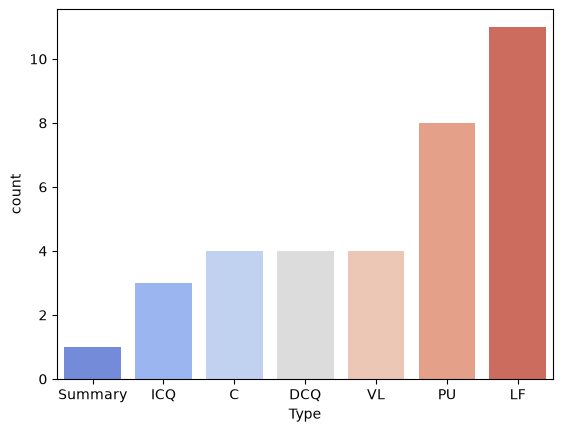

In [383]:
sns.barplot(avg_question_num, x="Type", y='count', hue='Type', palette='coolwarm')

In [384]:
paper_eda = paper_cleaned.groupby(["ID", "Type"])['Question Total'].sum().reset_index()
paper_eda

,ID,Type,Question Total
0,2020NOV,C,17
1,2020NOV,DCQ,9
2,2020NOV,ICQ,7
3,2020NOV,LF,19
4,2020NOV,PU,29
...,...,...,...
72,2025NOV,ICQ,8
73,2025NOV,LF,27
74,2025NOV,PU,14
75,2025NOV,Summary,10


In [385]:
# Average question type mark total per examination

avg_questions = paper_eda.groupby('Type')['Question Total'].mean().round(2).reset_index().sort_values('Question Total')

avg_questions

,Type,Question Total
2,ICQ,9.55
5,Summary,10.00
6,VL,10.73
1,DCQ,11.36
0,C,17.55
3,LF,20.00
4,PU,20.82


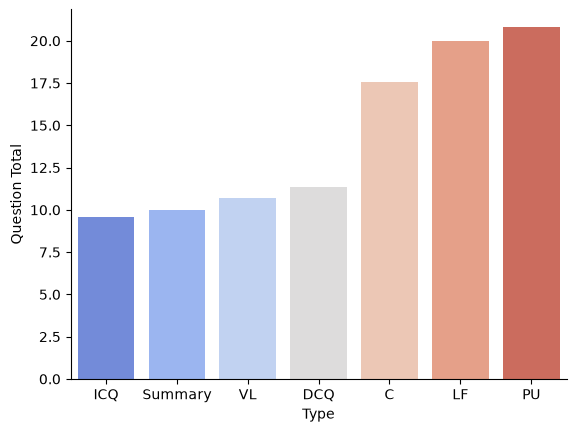

In [386]:
sns.barplot(avg_questions, x='Type', y='Question Total', hue='Type', palette='coolwarm')

sns.despine()

# Can tweak lables etc. with matplotlib: title, labels need work, full text of question types inside bars. 


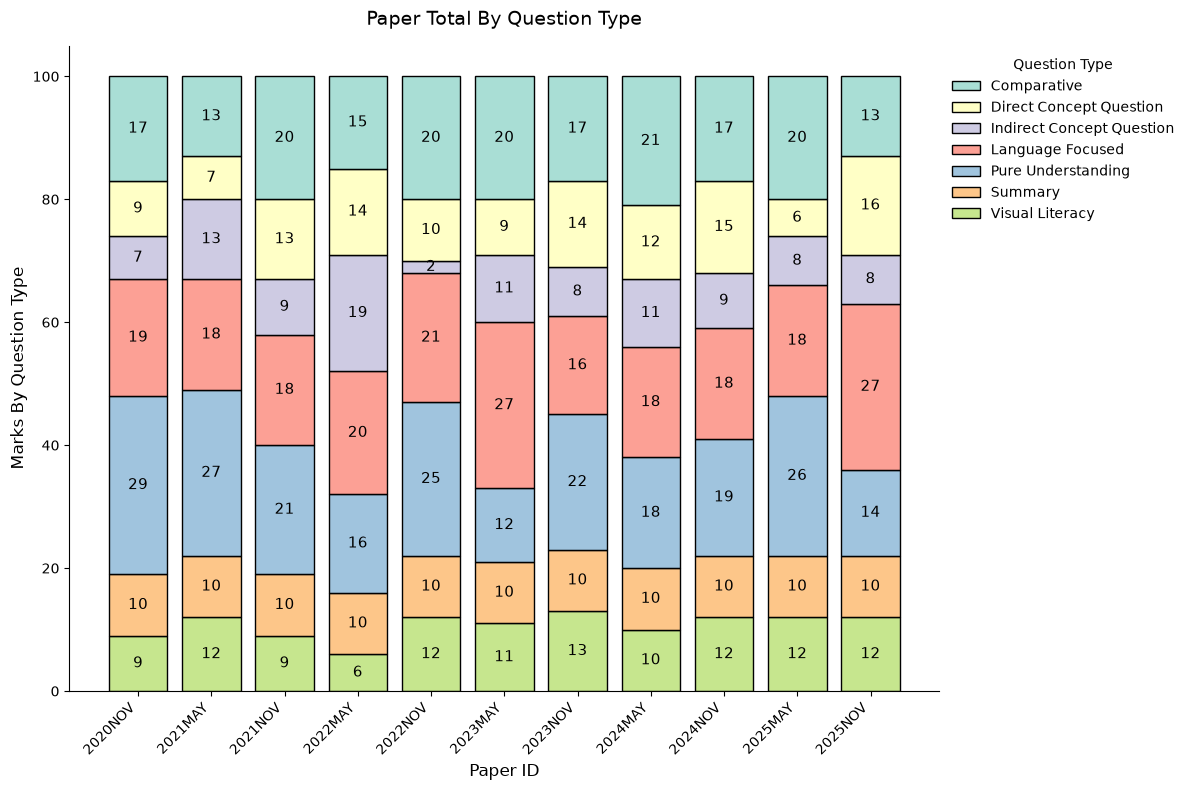

In [387]:
#Trends over time
plt.figure(figsize=(12, 8))
ax = sns.histplot(
    data=paper_eda,
    x="ID",
    weights="Question Total",  # Sets the bar height to your numeric values
    hue="Type",  # Stacks by question type
    multiple="stack",  # Enables stacking
    shrink=0.8, 
    palette='Set3' # Leaves small gaps between bars for readability
)

new_labels = [
    "Comparative",
    "Direct Concept Question",
    "Indirect Concept Question",
    "Language Focused",
    "Pure Understanding",
    "Summary",
    "Visual Literacy",
]

# 2. Add labels inside each segment of the stack
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%g",  # Formats numbers cleanly (e.g., 17 instead of 17.0)
        label_type="center",  # Centers the text inside each segment
        fontsize=11,
        color="black",  # White text stands out well on colored bars
        #fontweight="bold",
    )
plt.title("Paper Total By Question Type", fontsize=14, pad=15)
plt.xlabel("Paper ID", fontsize=12)
plt.ylabel("Marks By Question Type", fontsize=12)
plt.xticks(rotation=45, ha="right")



# Move legend outside AND customize title + label text
sns.move_legend(
    ax,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Question Type",
    labels=new_labels,
    frameon=False,
)



sns.despine()
plt.tight_layout()
plt.show()

### Takeaways:

1. There are no patterns of increasing/decreasing types of questions being asked. (Pure Understanding may have a slight decreasing trend).
2. Summary, Visual Literacy, and Comparative sectionsQuestions do not have much variation. 
3. There is substantial variation in Pure Understanding VS Language Focused Questions VS Concept based questions.  

</br>

Comparing the last two papers to extremes are evident:

The 2025 November Paper had an extreme focus on knowledge of Language and Concepts (55%). 

- Students who prepared; who knew understood common language questions and how to apply concepts had a huge advantage. Studying mattered enormously. The only other paper that came close to this focus on knowledge and application was May 2022. 

The 2025 May paper was an extreme contrast. The focus on language and concept knowledge application was far lower at only 32%. 

- This paper has more of an emphasis on baseline understanding and comprehension ability. These are the skills for which there is no real quick fix. This involves building vocabulary, reading regularly, and being able to infer meaning.   

</br>

#### The bottom line:

Preparing for English Paper 1 can be frustrating; some years reward study and knowledge of concepts more than others. Even in the extreme cases where language and concept knowledge only account for 32% of the paper, you are not going to attain a distinction or even above 70% without basic knowledge of concepts and language and grammar. 

</br>

#### Which paper type is harder?

Difficult question to answer. I would say that November 2025 was the easier paper because it depended so much on study and knowledge. It is easy to make improvements in such a paper. Whether or not students are actually taking advantage of how much preparation/study could have benefited them in such a paper is another question. 

There is more of a hard ceiling on the 2025 May Paper. In terms of how a student can prepare, this is the more challenging paper. The emphasis here falls on long term reading and inference ability resting more on vocabulary and wholistically understanding. 

</br>

#### Future Investigation

The hypothesis is that in light of a declining literacy and reading culture, Paper 2 is more difficult. A full investigation would have to look at the distribution and mean of students responses to the question types. 

</br>

#### What I would do as a student

I would make sure I completed two very different papers. In this case, May 2025 and November 2025. An analysis of the papers would show me which question types I most struggle with. In particular, my results for the November 2025 paper would give me more valuable knowledge about areas I could quickly improve upon. 







## EDA of Language Questions

Language Focused(LF) questions account for, on average, approximately 19% of every paper. This is a key focus area. It is easy to improve in for most questions.

Guiding Questions:

- What are the different
-

In [388]:
paper_cleaned.head()

,ID,Question,Section,Type,Subskill,Keywords,Remembering,Understanding,Applying,Analysing,Evaluating,Creating,Question Total,count
0,2025NOV,1.1,Comp,ICQ,style,style,0,1,0,1,0,0,2,1
1,2025NOV,1.2,Comp,DCQ,fos,metaphor,0,1,1,1,0,0,3,1
2,2025NOV,1.3,Comp,PU,argumentation,positions,1,1,1,1,0,0,4,1
3,2025NOV,1.4,Comp,LF,sentence structure,rhetorical questions,1,0,1,1,0,0,3,1
4,2025NOV,1.5,Comp,DCQ,diction,intention/tone/diction,0,2,1,1,0,0,4,1


In [389]:
questions_LF = paper_cleaned[paper_cleaned['Type'] == 'LF']
questions_LF.head()


,ID,Question,Section,Type,Subskill,Keywords,Remembering,Understanding,Applying,Analysing,Evaluating,Creating,Question Total,count
3,2025NOV,1.4,Comp,LF,sentence structure,rhetorical questions,1,0,1,1,0,0,3,1
9,2025NOV,3.1,Seen,LF,punctuation,rhythm,0,1,0,1,1,0,3,1
10,2025NOV,3.2,Seen,LF,language,pronouns,0,0,1,1,0,0,2,1
19,2025NOV,5.1,Crit,LF,sentence structure,imperative declarative iterrogative,0,1,1,1,0,0,3,1
20,2025NOV,5.2.1,Crit,LF,error,full sentence,1,0,0,0,0,0,1,1


In [390]:
questions_LF_count = questions_LF.groupby(['Subskill'])['count'].sum().reset_index()


In [391]:
# Language Focused Breakdown

LF_eda = questions_LF.groupby(['ID', 'Subskill'])['Question Total'].sum().reset_index()


new_labels = {
    'error' :'Common Errors',
    'language':'General Language',
    'punctuation':'Punctuation',
    'sentence structure':'Sentence Structure',
}

LF_eda['Subskill'] = LF_eda['Subskill'].map(new_labels)

LF_eda.sort_values('ID', inplace=True)


ID_list = LF_eda['ID'].unique()

ID_list

LF_eda.head()

,ID,Subskill,Question Total
0,2020NOV,Common Errors,4
1,2020NOV,General Language,1
2,2020NOV,Punctuation,8
3,2020NOV,Sentence Structure,6
4,2021MAY,Common Errors,2


In [392]:
# plt.figure(figsize=(10, 7))
# ax = sns.histplot(
#     LF_eda, 
#     x='ID', 
#     weights= 'Question Total', 
#     hue='Subskill', 
#     multiple='stack',
#     shrink=0.8, 
#     palette='tab20' )

# plt.title("Breakdown of Language Focused (LF) Questions", fontsize=14, pad=15)
# plt.xlabel("Paper ID", fontsize=12)
# plt.ylabel("Marks By Question Type", fontsize=12)
# plt.xticks(rotation=45, ha="right")


# sns.move_legend(
#     ax,
#     loc='upper left',
#     title="Language Subskills: \n",  # Custom legend title
#     fontsize=10,  # Label font size
#     title_fontsize=11,  # Title font size
# )

# plt.tight_layout()
# sns.despine()
# plt.show()

fig = px.bar(
    LF_eda,
    x="ID",
    y="Question Total", 
    color="Subskill",  
    barmode="stack",  
    color_discrete_sequence=px.colors.qualitative.Set2, 
    template="simple_white",  
    title="Breakdown of Language Focused (LF) Questions:",
    text= "Question Total", 
    labels={
        "ID": "Paper ID",
        "Question Total": "Marks By Subskill",
        "Subskill_Clean": "Language Subskills:",
    
    },
    category_orders={
        "ID": ID_list
    }
)

# Custom layout and axis formatting
fig.update_layout(
    width=800,
    height=560,
    title_font_size=18,
    xaxis_tickangle=-45,  
    legend=dict(
        title_text="Subskills (click to select)",
        orientation="v",
        x=1.02,
        y=1.0,
        xanchor="left",
        yanchor="top",
        font=dict(size=10),
        title_font=dict(size=11),
    ),
    bargap=0.2,
    
)

fig.show()





In [393]:

"#e78ac3" #(Pink)
"#8da0cb" #(Soft Blue / Periwinkle)
"#fc8d62" #(Coral / Orange)
"#a6d854" #(Lime Green)

'#a6d854'

In [394]:
#Count of language concepts across all papers

language_qtypes = paper_cleaned[paper_cleaned['Subskill'] == 'sentence structure']
language_qtypes.head()

language_qtypes = language_qtypes[['ID', 'Question', 'Keywords', 'count', 'Question Total']]
language_qtypes.head()

,ID,Question,Keywords,count,Question Total
3,2025NOV,1.4,rhetorical questions,1,3
19,2025NOV,5.1,imperative declarative iterrogative,1,3
25,2025NOV,5.5.1,simple compound complex,1,2
26,2025NOV,5.5.2,evaluate effectiveness (two sentences),1,2
36,2025NOV,6.5.1,subject verb object,1,1


In [395]:
language_skills = language_qtypes.groupby('Keywords')[['count', 'Question Total']].sum().reset_index()
language_skills.sort_values('count', ascending=False, inplace=True)
language_skills.head()


,Keywords,count,Question Total
2,evaluate effectiveness (two sentences),7,16
6,rhetorical questions,6,14
3,imperative declarative iterrogative,5,14
8,subject verb object,5,7
0,active/passive voice,3,4


In [396]:
fig = px.bar(
    language_skills,
    x="count",
    y="Keywords",
    title = "Frequency of all concepts appearing in General Language",
    subtitle= "Taken from papers spanning 2020-2025",
    color = "Keywords",
    color_discrete_sequence=['#fc8d62'],
    orientation= 'h',
    text='Keywords',
    template='plotly_white'
    )

fig.update_layout(
    showlegend=False,
    yaxis_title = 'Concepts',
    xaxis_title = 'Frequency of Concept From 2020-2025',    
)
fig.update_yaxes(          
    showticklabels=False  
)

fig.update_traces(
    textposition="inside",
    textfont=dict(weight="bold")  # Makes all bar text bold
)

fig.show()


### Saving and exporting data



In [397]:
paper_cleaned.head()

,ID,Question,Section,Type,Subskill,Keywords,Remembering,Understanding,Applying,Analysing,Evaluating,Creating,Question Total,count
0,2025NOV,1.1,Comp,ICQ,style,style,0,1,0,1,0,0,2,1
1,2025NOV,1.2,Comp,DCQ,fos,metaphor,0,1,1,1,0,0,3,1
2,2025NOV,1.3,Comp,PU,argumentation,positions,1,1,1,1,0,0,4,1
3,2025NOV,1.4,Comp,LF,sentence structure,rhetorical questions,1,0,1,1,0,0,3,1
4,2025NOV,1.5,Comp,DCQ,diction,intention/tone/diction,0,2,1,1,0,0,4,1


In [398]:
paper_df_edited = paper_cleaned[['ID', 'Question', 'Section', 'Type', 'Question Total']]
paper_df_edited.head()

,ID,Question,Section,Type,Question Total
0,2025NOV,1.1,Comp,ICQ,2
1,2025NOV,1.2,Comp,DCQ,3
2,2025NOV,1.3,Comp,PU,4
3,2025NOV,1.4,Comp,LF,3
4,2025NOV,1.5,Comp,DCQ,4


In [399]:
paper_df_edited.to_pickle("data/paper1_edit.pkl")

In [400]:
paper_df_edited[paper_df_edited['ID'] == '2025NOV']

,ID,Question,Section,Type,Question Total
0,2025NOV,1.1,Comp,ICQ,2
1,2025NOV,1.2,Comp,DCQ,3
2,2025NOV,1.3,Comp,PU,4
3,2025NOV,1.4,Comp,LF,3
4,2025NOV,1.5,Comp,DCQ,4
5,2025NOV,1.6,Comp,ICQ,3
6,2025NOV,1.7,Comp,PU,2
7,2025NOV,1.8,Comp,C,4
8,2025NOV,2.0,Summary,Summary,10
9,2025NOV,3.1,Seen,LF,3


In [401]:
no_bloom = paper_cleaned[["ID", "Question", "Section", "Type", "Subskill", "Keywords", "Question Total", "count"]]

no_bloom.head()

,ID,Question,Section,Type,Subskill,Keywords,Question Total,count
0,2025NOV,1.1,Comp,ICQ,style,style,2,1
1,2025NOV,1.2,Comp,DCQ,fos,metaphor,3,1
2,2025NOV,1.3,Comp,PU,argumentation,positions,4,1
3,2025NOV,1.4,Comp,LF,sentence structure,rhetorical questions,3,1
4,2025NOV,1.5,Comp,DCQ,diction,intention/tone/diction,4,1


In [402]:
no_bloom.to_pickle("data/no_bloom.pkl")

In [403]:
list_papers = paper_eda['ID'].unique()

print(list_papers)

<ArrowStringArray>
['2020NOV', '2021MAY', '2021NOV', '2022MAY', '2022NOV', '2023MAY', '2023NOV',
 '2024MAY', '2024NOV', '2025MAY', '2025NOV']
Length: 11, dtype: str


In [404]:
paper_eda[paper_eda['ID'].isin(['2020NOV', '2021MAY'])]

,ID,Type,Question Total
0,2020NOV,C,17
1,2020NOV,DCQ,9
2,2020NOV,ICQ,7
3,2020NOV,LF,19
4,2020NOV,PU,29
5,2020NOV,Summary,10
6,2020NOV,VL,9
7,2021MAY,C,13
8,2021MAY,DCQ,7
9,2021MAY,ICQ,13
